In [ ]:
# Read aws credentials from csv file and set as environment variables for Vault configuration
import csv, os
with open('vault_test_accessKeys.csv', 'r', encoding='utf-8-sig') as csvfile:
    reader = csv.DictReader(csvfile)
    creds = next(reader)
    access_key = creds['Access key ID']
    secret_key = creds['Secret access key']
    os.environ['AWS_ACCESS_KEY_ID'] = access_key
    os.environ['AWS_SECRET_ACCESS_KEY'] = secret_key
    print(f"Access Key: {access_key[:8]}...")
    print(f"Credentials loaded.")

# AWS Secret Engine

In [ ]:
! open -a Podman\ Desktop

In [ ]:
%env VAULT_ADDR=http://127.0.0.1:8200
%env VAULT_TOKEN=root
%env VAULT_KMIP_PORT=5696
%env VAULT_PORT=8200
%env REGION=eu-west-3

### Create a Vault Server in Podman

In [ ]:
%%bash
# Change the path to your license file

export VAULT_LICENSE=$(cat vault.hclic)

# Refresh Vault docker image with latest version
podman pull hashicorp/vault-enterprise

podman run -d --rm --name vault-enterprise --cap-add=IPC_LOCK \
  -e "VAULT_DEV_ROOT_TOKEN_ID=${VAULT_TOKEN}" \
  -e "VAULT_DEV_LISTEN_ADDRESS=:${VAULT_PORT}" \
  -e "VAULT_LICENSE=${VAULT_LICENSE}" \
  -p ${VAULT_KMIP_PORT}:${VAULT_KMIP_PORT} \
  -p 8200:${VAULT_PORT} \
  hashicorp/vault-enterprise:latest

### Check if Vault is running

In [ ]:
! podman ps

## Enable the AWS secrets engine

In [ ]:
! vault secrets enable aws

### Create `vault-root` IAM User
Vault's `aws/config/root` credentials need broad IAM permissions to manage dynamic users, rotate keys, etc.  
We create a dedicated `vault-root` IAM user with the [IAM permissions policy recommended by Vault](https://developer.hashicorp.com/vault/docs/secrets/aws#iam-permissions-policy-for-vault).

In [ ]:
%%bash
ACCOUNT_ID=$(aws sts get-caller-identity --query 'Account' --output text)
IAM_USER="vault-root"

echo "Account ID: $ACCOUNT_ID"
echo "User:       $IAM_USER"

# Create IAM user (skip if already exists)
if aws iam get-user --user-name "$IAM_USER" &>/dev/null; then
    echo "IAM user $IAM_USER already exists, skipping creation."
else
    aws iam create-user --user-name "$IAM_USER"
    echo "IAM user created."
fi

# Create the Vault IAM permissions policy (from Vault docs)
# Adding permissions for app-test user as well to allow testing with both vault-root and app-test users
POLICY_NAME="VaultIAMPolicy"
POLICY_ARN="arn:aws:iam::${ACCOUNT_ID}:policy/${POLICY_NAME}"

cat > /tmp/vault-iam-policy.json <<EOF
{
  "Version": "2012-10-17",
  "Statement": [
    {
      "Effect": "Allow",
      "Action": [
        "iam:AttachUserPolicy",
        "iam:CreateAccessKey",
        "iam:CreateUser",
        "iam:DeleteAccessKey",
        "iam:DeleteUser",
        "iam:DeleteUserPolicy",
        "iam:DetachUserPolicy",
        "iam:GetUser",
        "iam:ListAccessKeys",
        "iam:ListAttachedUserPolicies",
        "iam:ListGroupsForUser",
        "iam:ListUserPolicies",
        "iam:PutUserPolicy",
        "iam:AddUserToGroup",
        "iam:RemoveUserFromGroup",
        "iam:TagUser"
      ],
      "Resource": [
        "arn:aws:iam::${ACCOUNT_ID}:user/vault-*",
        "arn:aws:iam::${ACCOUNT_ID}:user/app-test"
      ]
    }
  ]
}
EOF

# Create or update the IAM policy
if aws iam get-policy --policy-arn "$POLICY_ARN" &>/dev/null; then
    echo "Policy $POLICY_NAME already exists, creating new version..."
    # Delete oldest non-default version if there are 5 versions (AWS limit)
    OLD_VERSION=$(aws iam list-policy-versions --policy-arn "$POLICY_ARN" \
        --query 'Versions[?IsDefaultVersion==`false`]|[-1].VersionId' --output text)
    if [ "$OLD_VERSION" != "None" ] && [ -n "$OLD_VERSION" ]; then
        aws iam delete-policy-version --policy-arn "$POLICY_ARN" --version-id "$OLD_VERSION" 2>/dev/null || true
    fi
    aws iam create-policy-version --policy-arn "$POLICY_ARN" \
        --policy-document file:///tmp/vault-iam-policy.json --set-as-default
else
    aws iam create-policy --policy-name "$POLICY_NAME" \
        --policy-document file:///tmp/vault-iam-policy.json
fi

# Attach the policy to vault-root user
aws iam attach-user-policy --user-name "$IAM_USER" --policy-arn "$POLICY_ARN"
echo "Policy $POLICY_NAME attached to $IAM_USER."

# Delete all existing access keys (AWS limit is 2)
echo ""
echo "Cleaning up old access keys..."
for old_key in $(aws iam list-access-keys --user-name "$IAM_USER" --query 'AccessKeyMetadata[*].AccessKeyId' --output text); do
    echo "  Deleting key: $old_key"
    aws iam delete-access-key --user-name "$IAM_USER" --access-key-id "$old_key"
done

# Create a new access key
echo ""
echo "Creating new access key..."
aws iam create-access-key --user-name "$IAM_USER" \
    --query 'AccessKey.[AccessKeyId,SecretAccessKey]' \
    --output text | while read key secret; do
    echo "VAULT_IAM_ACCESS_KEY=$key"
    echo "VAULT_IAM_SECRET_KEY=$secret"
done

### Set `vault-root` Credentials
Copy the `VAULT_IAM_ACCESS_KEY` and `VAULT_IAM_SECRET_KEY` values from the output above.

In [ ]:
%env VAULT_IAM_ACCESS_KEY=AKI*****
%env VAULT_IAM_SECRET_KEY=GJ2o0ee6****

In [ ]:
%%bash
# Configure Vault AWS secrets engine with static IAM user credentials
vault write aws/config/root \
    access_key=$VAULT_IAM_ACCESS_KEY \
    secret_key=$VAULT_IAM_SECRET_KEY \
    region=$REGION

## Rotate root credentials

In [ ]:
! vault write -f aws/config/rotate-root

### Create `app-test` IAM User (for Static Role)
This user simulates an application's IAM identity. Vault will manage (rotate) its access keys via a [Static Role](https://developer.hashicorp.com/vault/docs/secrets/aws#static-roles).  
We give it a simple EC2 read-only policy so we can verify the credentials work.

In [ ]:
%%bash
ACCOUNT_ID=$(aws sts get-caller-identity --query 'Account' --output text)
IAM_USER="app-test"

echo "Account ID: $ACCOUNT_ID"
echo "User:       $IAM_USER"

# Create IAM user (skip if already exists)
if aws iam get-user --user-name "$IAM_USER" &>/dev/null; then
    echo "IAM user $IAM_USER already exists, skipping creation."
else
    aws iam create-user --user-name "$IAM_USER"
    echo "IAM user created."
fi

# Create a simple EC2 read-only policy for the app
POLICY_NAME="AppTestEC2ReadOnly"
POLICY_ARN="arn:aws:iam::${ACCOUNT_ID}:policy/${POLICY_NAME}"

cat > /tmp/app-test-policy.json <<EOF
{
  "Version": "2012-10-17",
  "Statement": [
    {
      "Effect": "Allow",
      "Action": [
        "ec2:DescribeRegions",
        "ec2:DescribeInstances",
        "kms:ListKeys",
        "sts:GetCallerIdentity"
      ],
      "Resource": "*"
    }
  ]
}
EOF

# Create or update the IAM policy
if aws iam get-policy --policy-arn "$POLICY_ARN" &>/dev/null; then
    echo "Policy $POLICY_NAME already exists, creating new version..."
    OLD_VERSION=$(aws iam list-policy-versions --policy-arn "$POLICY_ARN" \
        --query 'Versions[?IsDefaultVersion==`false`]|[-1].VersionId' --output text)
    if [ "$OLD_VERSION" != "None" ] && [ -n "$OLD_VERSION" ]; then
        aws iam delete-policy-version --policy-arn "$POLICY_ARN" --version-id "$OLD_VERSION" 2>/dev/null || true
    fi
    aws iam create-policy-version --policy-arn "$POLICY_ARN" \
        --policy-document file:///tmp/app-test-policy.json --set-as-default
else
    aws iam create-policy --policy-name "$POLICY_NAME" \
        --policy-document file:///tmp/app-test-policy.json
fi

# Attach the policy to app-test user
aws iam attach-user-policy --user-name "$IAM_USER" --policy-arn "$POLICY_ARN"
echo "Policy $POLICY_NAME attached to $IAM_USER."

# Delete all existing access keys (AWS limit is 2)
echo ""
echo "Cleaning up old access keys..."
for old_key in $(aws iam list-access-keys --user-name "$IAM_USER" --query 'AccessKeyMetadata[*].AccessKeyId' --output text); do
    echo "  Deleting key: $old_key"
    aws iam delete-access-key --user-name "$IAM_USER" --access-key-id "$old_key"
done

# Create a new access key (Vault static roles need an initial key to exist)
echo ""
echo "Creating initial access key for $IAM_USER..."
aws iam create-access-key --user-name "$IAM_USER" \
    --query 'AccessKey.[AccessKeyId,SecretAccessKey]' \
    --output text | while read key secret; do
    echo "Initial Access Key: $key"
    echo "(Vault will rotate this key automatically)"
done

### Configure Vault Static Role for `app-test`
A [static role](https://developer.hashicorp.com/vault/docs/secrets/aws#static-roles) is a 1-to-1 mapping of a Vault role to an IAM user.  
Vault stores the current access key and **automatically rotates** it on a configurable period (`rotation_period`).

In [ ]:
%%bash
# Create static role: Vault will manage app-test's access keys
# rotation_period = how often Vault rotates the key (e.g. 1h for demo)
vault write aws/static-roles/app-test \
    username=app-test \
    rotation_period=1h


### Test    

In [ ]:
%%bash
vault read aws/static-creds/app-test

In [ ]:
%%bash
vault read -output-curl-string aws/static-creds/app-test

### Verification — Read Static Credentials
Read the current access key managed by Vault for `app-test`, then use it to call AWS APIs.

In [ ]:
%%bash
# Read the static credentials that Vault manages for app-test
echo "=== Static Credentials ==="
vault read aws/static-creds/app-test

echo ""

# Use the static credentials to call AWS
CREDS=$(vault read -format=json aws/static-creds/app-test)
export AWS_ACCESS_KEY_ID=$(echo $CREDS | jq -r '.data.access_key')
export AWS_SECRET_ACCESS_KEY=$(echo $CREDS | jq -r '.data.secret_key')
unset AWS_SESSION_TOKEN  # static creds don't use session tokens

sleep 10  # Wait for AWS IAM to propagate the new key (eventual consistency)

echo "=== Caller Identity (using app-test static creds) ==="
aws sts get-caller-identity

echo ""

echo "=== EC2 Describe Regions ==="
aws ec2 describe-regions --query 'Regions[*].RegionName' --output table --region $REGION

echo ""

echo "=== EC2 Describe Instances ==="
aws ec2 describe-instances \
    --query 'Reservations[*].Instances[*].{ID:InstanceId,Type:InstanceType,State:State.Name,AZ:Placement.AvailabilityZone,Name:Tags[?Key==`Name`]|[0].Value}' \
    --output table --region $REGION

echo ""

echo "=== KMS List Keys ==="
aws kms list-keys --query 'Keys[*].KeyId' --output table --region $REGION

echo ""

# Note: Static role credentials rotate automatically based on rotation_period.
# There is no manual rotate endpoint for static roles.
# To see rotation details, read the static role config:
echo "=== Static Role Config (rotation_period) ==="
vault read aws/static-roles/app-test

# Static Secret with KVv2

In [ ]:
%%bash
# Enable Kvv2 secrets engine at path "secret/"
vault secrets enable -path=secretv2 kv-v2
# Create static secret with Kvv2 engine in path /secret/data/app-test
vault kv put secretv2/app-test username="app-test" password="s3cr3t"

# App Role

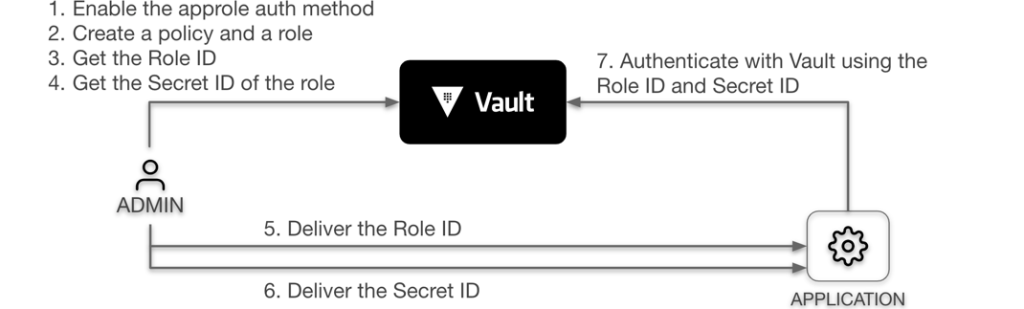

### Policy

In [ ]:
%%bash
# Create a policy that allows reading the aws static role and the Kvv2 secret
vault policy write app-test-policy - <<EOF
# Allow read access to the static credentials for app-test role
path "aws/static-creds/test" {
    capabilities = ["read"]
}
# Allow read access to the Kvv2 secret for app-test
path "secretv2/data/app-test" {
    capabilities = ["read"]
}
EOF


### Enable AppRole

In [ ]:
! vault auth enable approle

### Configure Approle named my-role with token with specific attributes

In [ ]:
%%bash
# Create an AppRole with a policy that allows reading the aws credentials
vault write auth/approle/role/my-role \
    policies=app-test-policy \
    token_ttl=20m \
    token_max_ttl=30m 

### Retrieve AppRole ID

In [ ]:
! vault read auth/approle/role/my-role/role-id

### Retrieve Secret ID

In [ ]:
! vault write -f auth/approle/role/my-role/secret-id

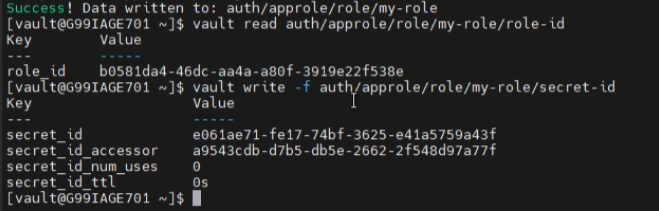

## Test AppRole

### With vault CLI

In [ ]:
%%bash
# Authenticate with the RoleID and SecretID to get a Vault token
ROLE_ID=$(vault read -field=role_id auth/approle/role/my-role/role-id)
SECRET_ID=$(vault write -field=secret_id -f auth/approle/role/my-role/secret-id)    
ROLE_TOKEN=$(vault write auth/approle/login role_id="$ROLE_ID" secret_id="$SECRET_ID" -format=json | jq -r '.auth.client_token')    
echo "AppRole Token: $ROLE_TOKEN"

# Use the AppRole token to read the AWS static credentials
echo ""
echo "=== Reading AWS Static Credentials with AppRole Token ==="
VAULT_TOKEN=$ROLE_TOKEN vault read aws/static-creds/test

# Use the AppRole token to read the Kvv2 secret
echo ""
echo "=== Reading Kvv2 Secret with AppRole Token ==="
VAULT_TOKEN=$ROLE_TOKEN vault kv get secretv2/app-test



### With curl

In [ ]:
%%bash
# Now using curl to authenticate with AppRole and read the static credentials
ROLE_ID=$(curl -s --header "X-Vault-Token: $VAULT_TOKEN" http://127.0.0.1:8200/v1/auth/approle/role/my-role/role-id | jq -r '.data.role_id')
SECRET_ID=$(curl -s --header "X-Vault-Token: $VAULT_TOKEN" -X POST http://127.0.0.1:8200/v1/auth/approle/role/my-role/secret-id | jq -r '.data.secret_id')
# ---
ROLE_TOKEN=$(curl -s -X POST http://127.0.0.1:8200/v1/auth/approle/login -d "{\"role_id\":\"$ROLE_ID\",\"secret_id\":\"$SECRET_ID\"}" | jq -r '.auth.client_token')
echo "AppRole Token: $ROLE_TOKEN"

# Use the AppRole token to read the AWS static credentials
echo ""
echo "=== Reading AWS Static Credentials with AppRole Token (using curl) ==="
curl -s --header "X-Vault-Token: $ROLE_TOKEN" http://127.0.0.1:8200/v1/aws/static-creds/test | jq -r 

# Use the AppRole token to read the Kvv2 secret
echo ""
echo "=== Reading Kvv2 Secret with AppRole Token (using curl) ==="
curl -s --header "X-Vault-Token: $ROLE_TOKEN" http://127.0.1:8200/v1/secretv2/data/app-test | jq -r 


### With JavaScript

In [ ]:
%%bash
# Retrieve AppRole credentials using the Vault CLI and run the Node.js app
ROLE_ID=$(vault read -field=role_id auth/approle/role/my-role/role-id)
SECRET_ID=$(vault write -field=secret_id -f auth/approle/role/my-role/secret-id)

echo "Role ID    : $ROLE_ID"
echo "Secret ID  : ${SECRET_ID:0:8}... (truncated)"
echo ""

# Pass credentials as env vars — the Node.js script uses ONLY these, no root token needed
VAULT_ADDR=http://127.0.0.1:8200 \
ROLE_ID="$ROLE_ID" \
SECRET_ID="$SECRET_ID" \
  node vault-approle-node/vault-approle.js

### Vault Agent

In [ ]:
%%bash
# Retrieve AppRole credential with Vault Agent.
# The Vault Agent will authenticate using the AppRole and write the token to /tmp/agent-token
cat > vault-agent.hcl <<EOF
pid_file = "/tmp/vault-agent.pid"
auto_auth {
    method "approle" {
        mount_path = "auth/approle"
        config = {
            role_id_file_path = "/tmp/approle-role-id"
            secret_id_file_path = "/tmp/approle-secret-id"
        }
    }
    sink "file" {
        config = {
            path = "/tmp/agent-token"
        }
    }
}

# Render KVv2 secret to a file
template {
    contents = <<TMPL
        {{- with secret "secretv2/data/app-test" }}
        username={{ .Data.data.username }}
        password={{ .Data.data.password }}
        {{- end }}
TMPL
    destination = "/tmp/app-test-secret.env"
    perms        = "0640"
}

# Render AWS static credentials to a file
template {
    contents = <<TMPL
    {{- with secret "aws/static-creds/app-test" }}
    AWS_ACCESS_KEY_ID={{ .Data.access_key }}
    AWS_SECRET_ACCESS_KEY={{ .Data.secret_key }}
    {{- end }}
TMPL
    destination = "/tmp/app-test-aws.env"
    perms        = "0640"
}

EOF
# Write the RoleID and SecretID to files for the Vault Agent
vault read -field=role_id auth/approle/role/my-role/role-id > /tmp/approle-role-id
vault write -field=secret_id -f auth/approle/role/my-role/secret-id > /tmp/approle-secret-id
# Start the Vault Agent in the background
# exit-after-auth is used here for demo purposes to stop the agent after it authenticates and renders the templates once. 
# In a real application, you would typically want the agent to keep running to handle token renewal and re-rendering templates on rotation.
vault agent -config=vault-agent.hcl -exit-after-auth & 
AGENT_PID=$!
echo "Vault Agent started with PID $AGENT_PID"

# Wait for the agent to write the token
while [ ! -f /tmp/agent-token ]; do
    echo "Waiting for Vault Agent to write token..."
    sleep 1
done
echo "Vault Agent token written to /tmp/agent-token"

AGENT_TOKEN=$(cat /tmp/agent-token)
echo "Agent Token: ${AGENT_TOKEN:0:8}... (truncated)"

# Wait for templates to render
while [ ! -f /tmp/app-test-secret.env ] || [ ! -f /tmp/app-test-aws.env ]; do
    echo "Waiting for templates to render..."
    sleep 1
done

echo ""
echo "=== Rendered KVv2 Secret (/tmp/app-test-secret.env) ==="
cat /tmp/app-test-secret.env

echo ""
echo "=== Rendered AWS Static Credentials (/tmp/app-test-aws.env) ==="
cat /tmp/app-test-aws.env

# Clean up

In [ ]:
%%bash
echo "=== Deleting Vault static roles and mounts ==="
vault delete aws/static-roles/app-test 2>/dev/null && echo "Deleted static role aws/static-roles/app-test" || true
vault secrets disable aws 2>/dev/null && echo "Disabled mount aws/" || true
echo "Done."

In [ ]:
%%bash
ACCOUNT_ID=$(aws sts get-caller-identity --query 'Account' --output text)

echo "=== Deleting IAM Users ==="
for USER in vault-root app-test vault-assumed test-assumed; do
    echo ""
    echo "--- Deleting user: $USER ---"

    # Delete access keys
    for KEY in $(aws iam list-access-keys --user-name "$USER" --query 'AccessKeyMetadata[*].AccessKeyId' --output text 2>/dev/null); do
        aws iam delete-access-key --user-name "$USER" --access-key-id "$KEY"
        echo "  Deleted access key: $KEY"
    done

    # Detach managed policies
    for POLICY_ARN in $(aws iam list-attached-user-policies --user-name "$USER" --query 'AttachedPolicies[*].PolicyArn' --output text 2>/dev/null); do
        aws iam detach-user-policy --user-name "$USER" --policy-arn "$POLICY_ARN"
        echo "  Detached policy: $POLICY_ARN"
    done

    # Delete inline policies
    for POLICY_NAME in $(aws iam list-user-policies --user-name "$USER" --query 'PolicyNames[*]' --output text 2>/dev/null); do
        aws iam delete-user-policy --user-name "$USER" --policy-name "$POLICY_NAME"
        echo "  Deleted inline policy: $POLICY_NAME"
    done

    # Delete the user
    aws iam delete-user --user-name "$USER" 2>/dev/null && echo "  User $USER deleted." || echo "  User $USER not found or already deleted."
done

echo ""
echo "=== AWS cleanup complete ==="

In [ ]:
%%bash
echo "=== Stopping Vault container ==="
podman stop vault-enterprise 2>/dev/null && echo "Vault container stopped." || echo "Vault container not running."
echo "=== All demo resources cleaned up ==="